### *EDDY MonIToring and Characterization from High rEsoLution alTimetry*

In [16]:
import glob
import sys
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings("ignore")
from datetime import datetime,date,timedelta
from netCDF4 import Dataset
from scipy.interpolate import griddata
#from swot_functions import *
#from detection_functions import *


###**********************************###
perc_thr=40
central_tol=0.6
Rmin=5
Amin=0.01
shape_err=85
###**********************************###


import matplotlib.path as mpath
import cartopy.crs as ccrs
import cartopy.feature as cfeature


def make_curved_map_north(
    lat_min=50,central_longitude=0,
    figsize=(6, 6),
    lafont=14,facecol='w'
):
    fig = plt.figure(figsize=figsize)
    ax = plt.subplot(
        1, 1, 1,
        projection=ccrs.NorthPolarStereo(central_longitude=central_longitude),fc=facecol
    )
    ax.set_extent([-180, 180, lat_min, 90], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor='grey', edgecolor='k', zorder=19)
    ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.2, zorder=20)

    gl = ax.gridlines(
        draw_labels=True,
        rotate_labels=False,
        x_inline=False,
        y_inline=False,
        linestyle='-',
        alpha=1#,zorder=1000
    )
    gl.xlabel_style = {'size': lafont}
    gl.ylabel_style = {'size': lafont}

    import matplotlib.ticker as mticker
    gl.xlocator = mticker.MultipleLocator(20)  # every 10° longitude
    theta = np.linspace(0, 2 * np.pi, 100)
    center, radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + np.array(center))

    ax.set_boundary(circle, transform=ax.transAxes)
    
    for lat in [60, 70, 80]:
        ax.text(
            0, lat,               # lon=45°
            f"{lat}°N",
            transform=ccrs.PlateCarree(),
            fontsize=8,
            ha='left',
            va='center',
            rotation=-20,
            zorder=20000
        )

    return fig, ax


def cut_the_map():
    import matplotlib.patches as mpatches
    lat_cut = 80
    lons = np.linspace(-180, 180, 400)
    lats = np.full_like(lons, lat_cut)
    verts = np.column_stack([lons, lats])
    pole = np.column_stack([lons[::-1], np.full_like(lons, 90)])
    poly = np.vstack([verts, pole])
    mask = mpatches.Polygon(
        poly,
        closed=True,
        facecolor='white',
        edgecolor='none',
        transform=ccrs.PlateCarree(),
        zorder=18
    )
    ax.add_patch(mask)

    top_mask = mpatches.Rectangle(
        (0, 0.515), 
        1, 0.5,
        transform=fig.transFigure,
        facecolor='white',
        edgecolor='none',
        zorder=10000
    )
    fig.add_artist(top_mask)


def OrdinalToDatetime(ordinal):
    plaindate = date.fromordinal(int(ordinal))
    date_time = datetime.combine(plaindate, datetime.min.time())
    return date_time + timedelta(days=ordinal-int(ordinal))

In [2]:
#for the northern hemishpere
path_data='../polar-swot-detection/2024-2025-v3.0/North/'

extraction_names=['Labrador-2425-v3_0',
                  'Irminger-2425-v3_0',
                  'Greenland-2425-v3_0',
                  'Baffin-2425-v3_0',
                  'Iceland-2425-v3_0',
                  'Norwegian-2425-v3_0',
                  'NA-2425-v3_0',
                  'Pacific3bis-2425-v3_0',
                  'Pacific4-2425-v3_0'
                 ]


In [11]:
# read the detection and associated parameters
lon_all_allareas={}
lat_all_allareas={}
contour_lon_all_allareas={}
contour_lat_all_allareas={}
ipass_all_allareas={}
pol_all_allareas={}
juld_all_allareas={}
cycle_all_allareas={}
cycles_avail=[]
r_all_allareas={}
v_all_allareas={}
a_all_allareas={}
ice_all_allareas={}
Rd_all_allareas={}
depth_all_allareas={}

for extraction_name in extraction_names:
    print(extraction_name)
    path_save=path_data+'detection_'+extraction_name+'/'
    namefile3='ice-topo-detection_'+'pt_'+str(perc_thr).zfill(2)+'_ct_'+str(central_tol).zfill(3)+'_Rmin_'+str(Rmin).zfill(2)+'_Amin_'+str(Amin).zfill(2)+'_shapeerror_'+str(shape_err).zfill(2)+'.nc'
    nc=Dataset(path_save+namefile)
    lon_all_allareas[extraction_name]=nc['lon'][:]
    lat_all_allareas[extraction_name]=nc['lat'][:]
    contour_lon_all_allareas[extraction_name]=nc['clon'][:] #need to save this one
    contour_lat_all_allareas[extraction_name]=nc['clat'][:]
    ipass_all_allareas[extraction_name]=nc['ipass'][:]
    pol_all_allareas[extraction_name]=nc['pol'][:]
    juld_all_allareas[extraction_name]=nc['juld'][:]
    cycle_all_allareas[extraction_name]=nc['cycle'][:]
    r_all_allareas[extraction_name]=nc['r'][:]
    v_all_allareas[extraction_name]=nc['v'][:]
    a_all_allareas[extraction_name]=nc['a'][:]
    nc.close()

    nc=Dataset(path_save+namefile3)
    depth_all_allareas[extraction_name]=nc['depth'][:]
    ice_all_allareas[extraction_name]=nc['ice_conc'][:]
    Rd_all_allareas[extraction_name]=nc['Rd'][:]
    nc.close()
    cycles_avail.append(np.unique(cycle_all_allareas[extraction_name]))
cycles_avail=np.unique(np.concatenate(cycles_avail))    
    

Labrador-2425-v3_0
Irminger-2425-v3_0
Greenland-2425-v3_0
Baffin-2425-v3_0
Iceland-2425-v3_0
Norwegian-2425-v3_0
NA-2425-v3_0
Pacific3bis-2425-v3_0
Pacific4-2425-v3_0


plot cycle #18 from 10/07/2024 to 30/07/2024
Labrador-2425-v3_0
452 eddies in this domain for this cycle
Irminger-2425-v3_0
382 eddies in this domain for this cycle
Greenland-2425-v3_0
422 eddies in this domain for this cycle
Baffin-2425-v3_0
106 eddies in this domain for this cycle
Iceland-2425-v3_0
360 eddies in this domain for this cycle
Norwegian-2425-v3_0
682 eddies in this domain for this cycle
NA-2425-v3_0
352 eddies in this domain for this cycle
Pacific3bis-2425-v3_0
2 eddies in this domain for this cycle
Pacific4-2425-v3_0
56 eddies in this domain for this cycle


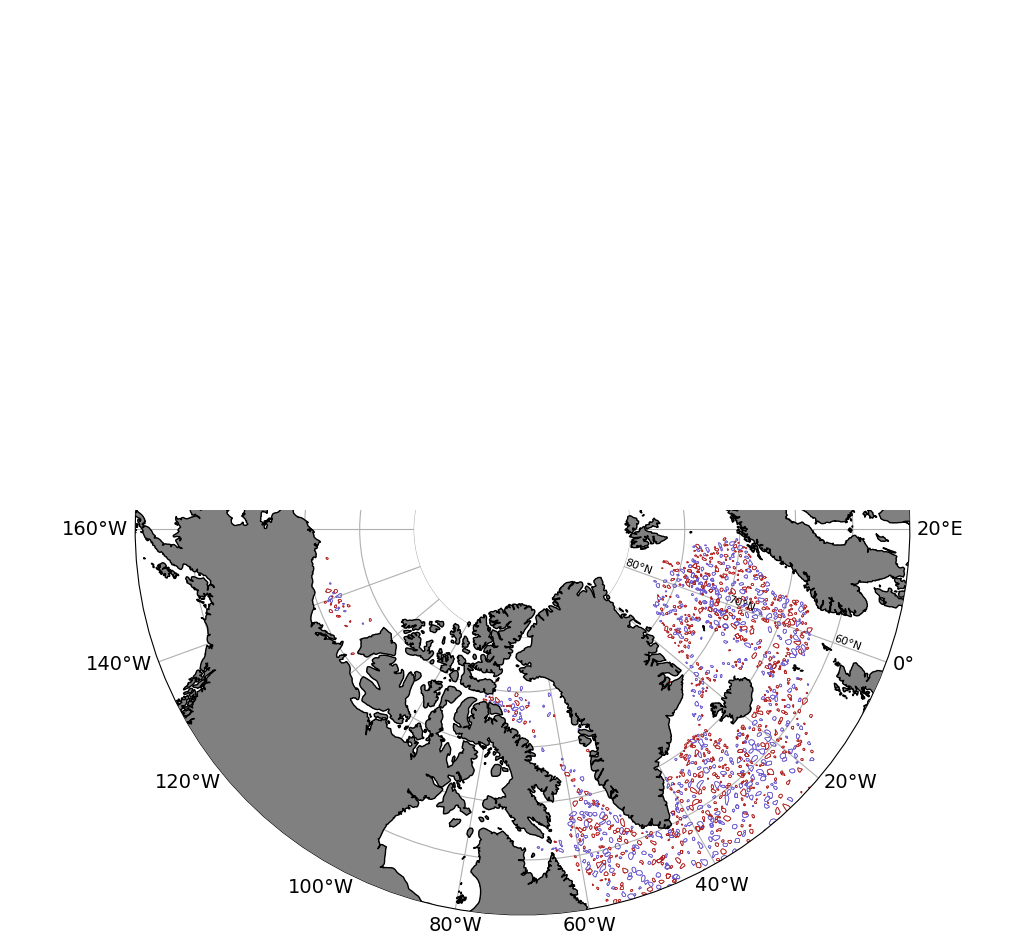

In [18]:
# plot the detection for one cycle
icycle=12

take_cycle=cycle_all_allareas[extraction_names[0]]==cycles_avail[icycle]
minjuld=np.nanmin(juld_all_allareas[extraction_names[0]][take_cycle])
maxjuld=np.nanmax(juld_all_allareas[extraction_names[0]][take_cycle])
print('plot cycle #{} from '.format(int(cycles_avail[icycle]))+OrdinalToDatetime(int(minjuld-1721424.5)).strftime("%d/%m/%Y")+' to '+OrdinalToDatetime(int(maxjuld-1721424.5)).strftime("%d/%m/%Y"))



#remove coastal and ice-covered eddies
min_depth=-500
max_ice_conc=0.15



fig,ax=make_curved_map_north(lat_min=55,central_longitude=-70,figsize=(10, 10))
for extraction_name in extraction_names[:]:
    print(extraction_name)
    take_cycle=cycle_all_allareas[extraction_name]==cycles_avail[icycle]
    icount=0
    for ieddy in range(len(lon_all_allareas[extraction_name])):

        if take_cycle[ieddy]==False:continue

        if depth_all_allareas[extraction_name][ieddy]>min_depth or np.isnan(depth_all_allareas[extraction_name][ieddy]):
            continue

        if ice_all_allareas[extraction_name][ieddy]>max_ice_conc:continue



        if pol_all_allareas[extraction_name][ieddy]==-1:thiscol='slateblue'
        elif pol_all_allareas[extraction_name][ieddy]==+1:thiscol='firebrick'    

        plt.plot(contour_lon_all_allareas[extraction_name][ieddy]-360,
                    contour_lat_all_allareas[extraction_name][ieddy],
                    '-',c=thiscol,lw=0.5,
                    transform=ccrs.PlateCarree())


        icount+=1
    print('{} eddies in this domain for this cycle'.format(icount))

cut_the_map()
plt.subplots_adjust(wspace=0.05) 
plt.show()

load detection


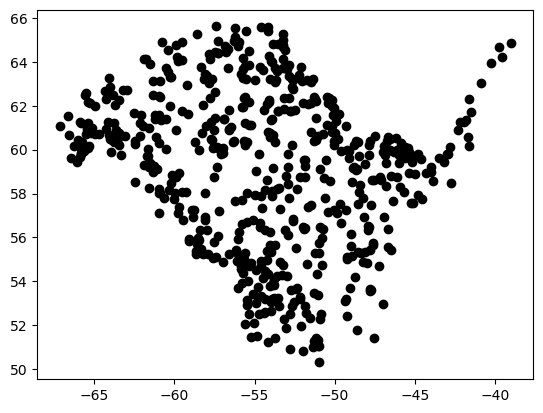

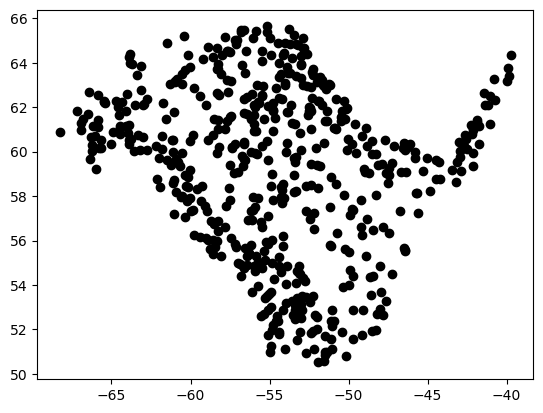

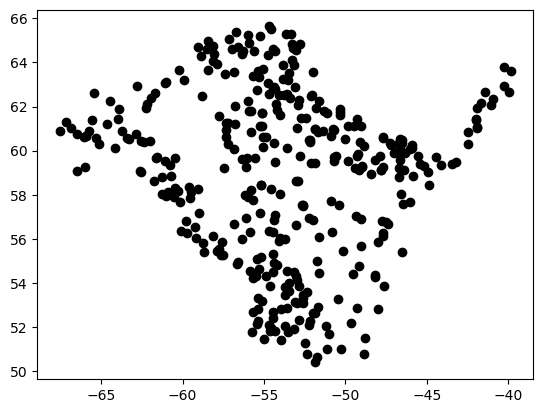

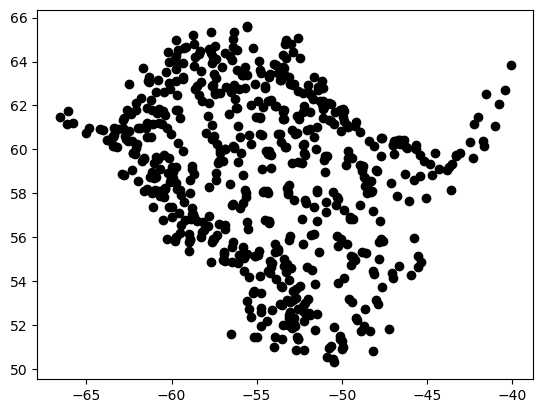

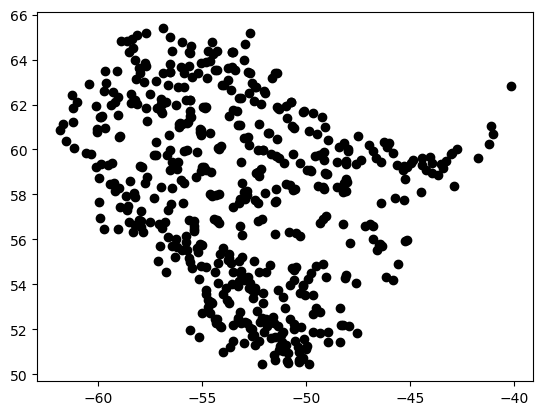

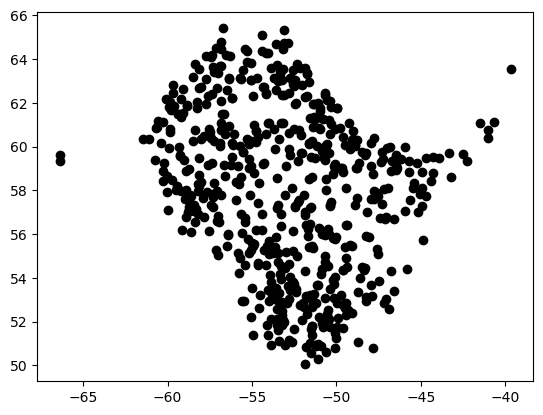

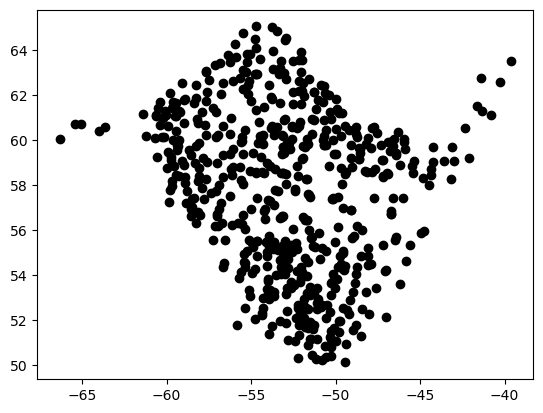

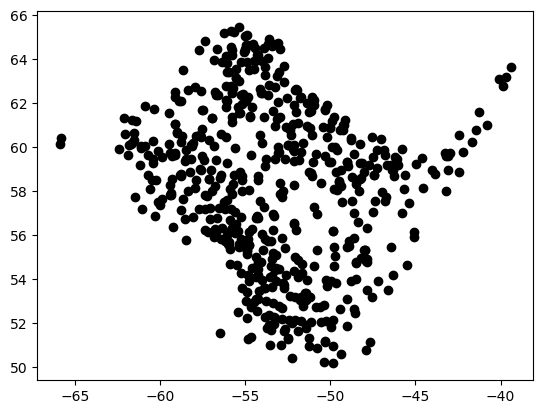

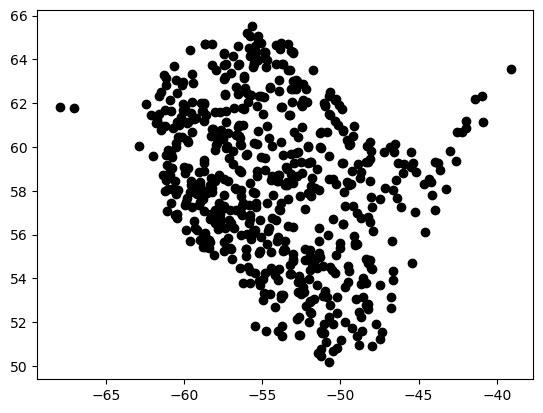

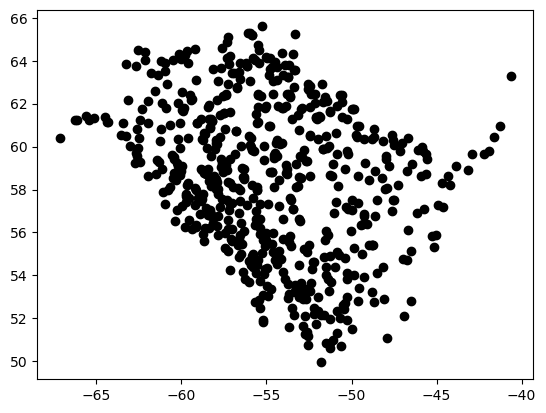

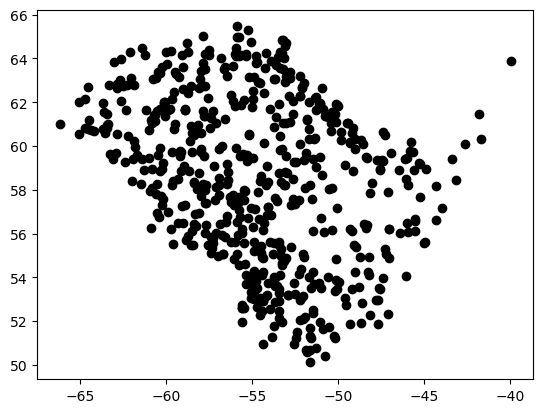

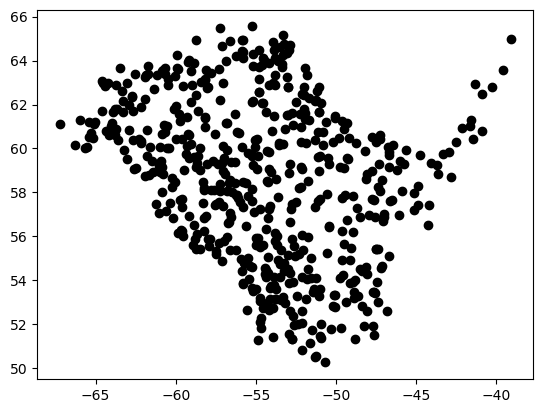

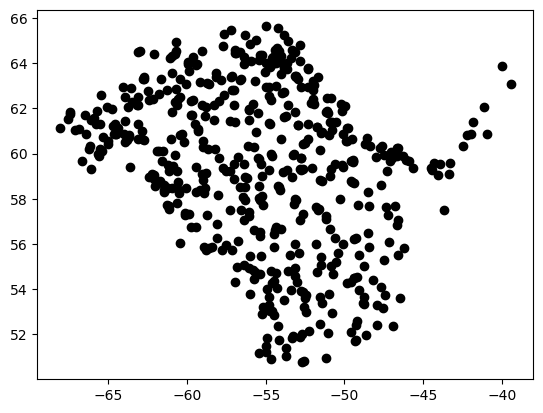

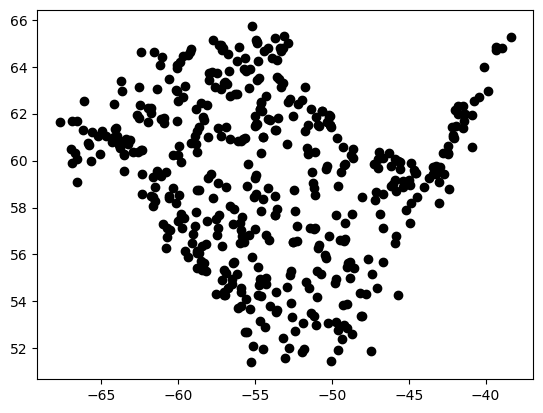

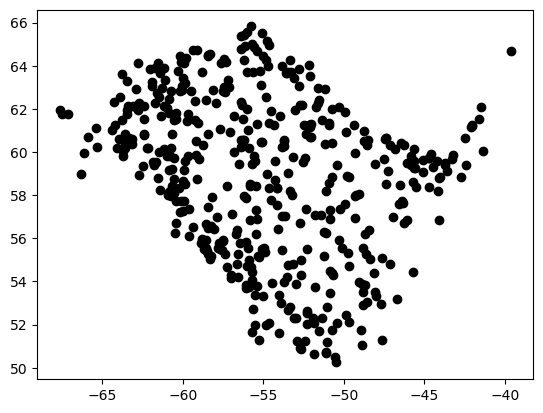

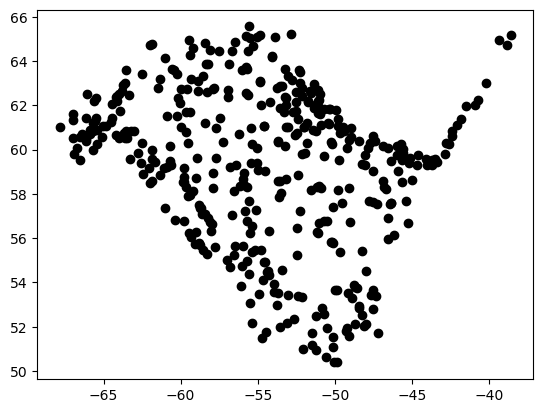

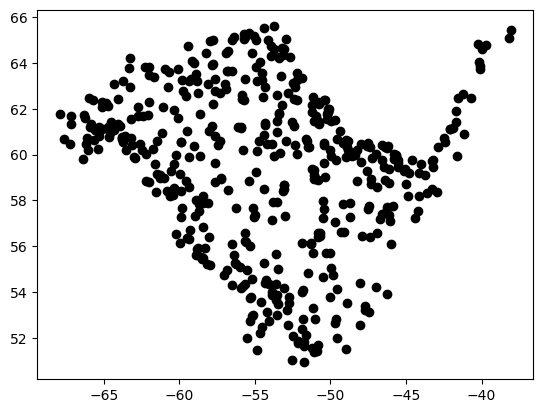

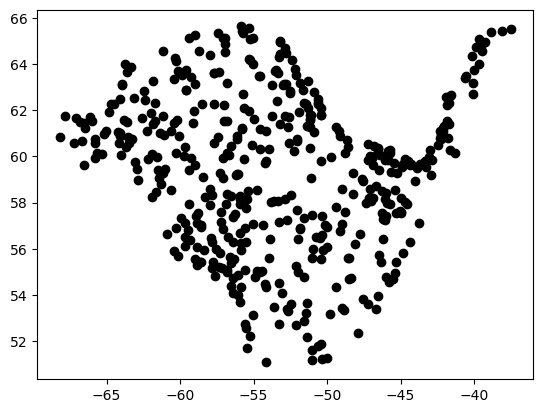

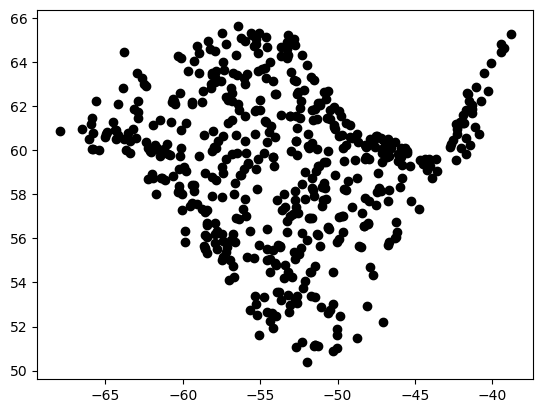

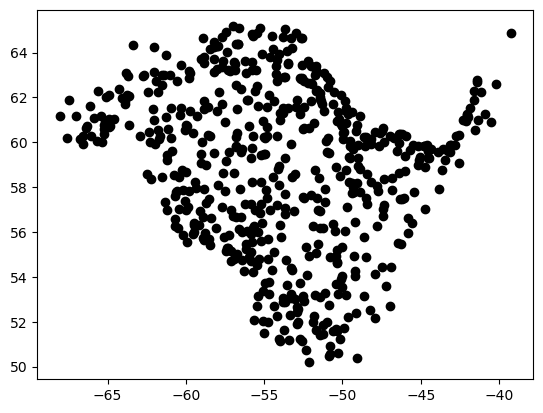

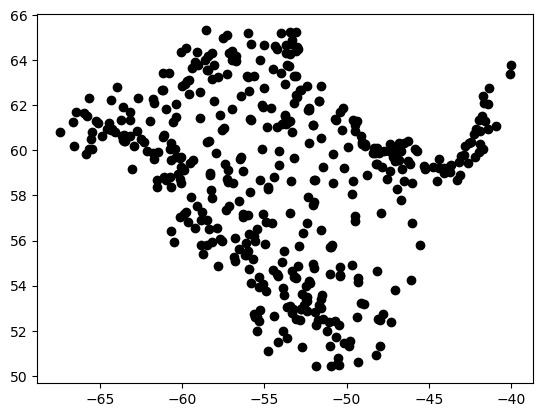

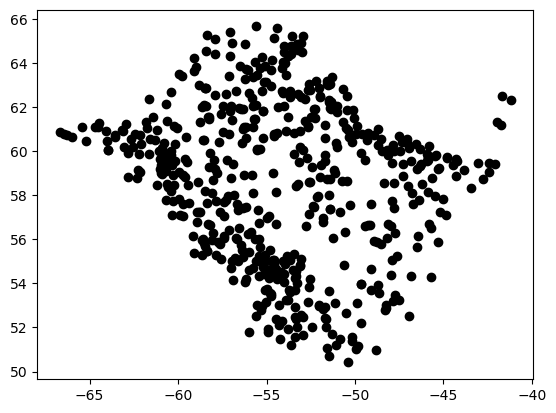

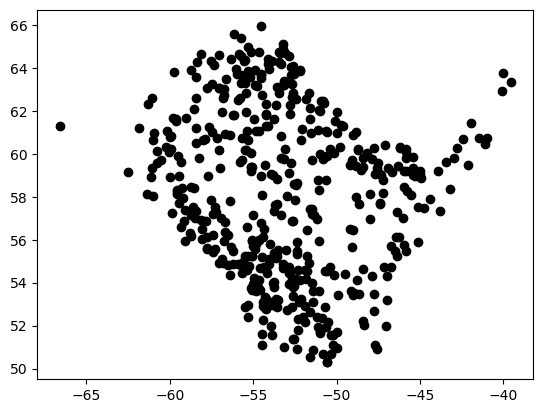

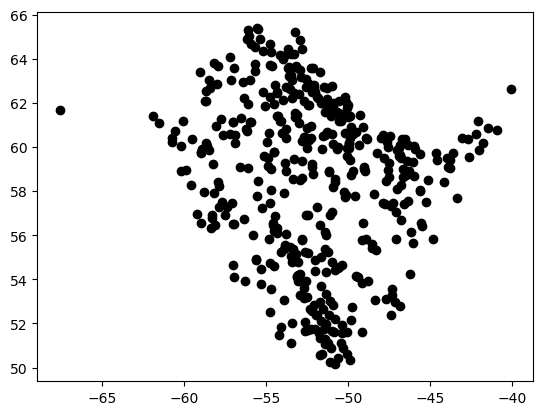

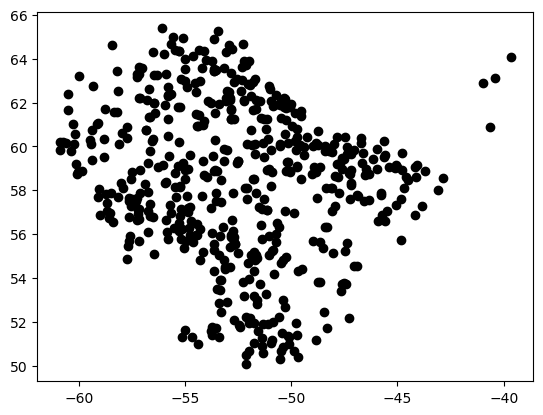

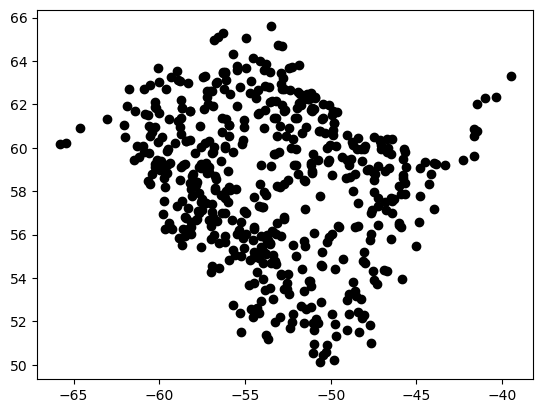

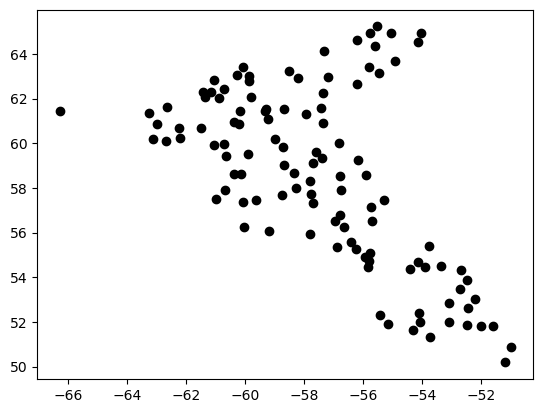

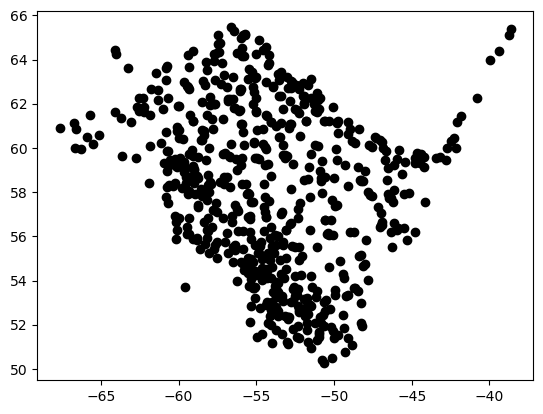

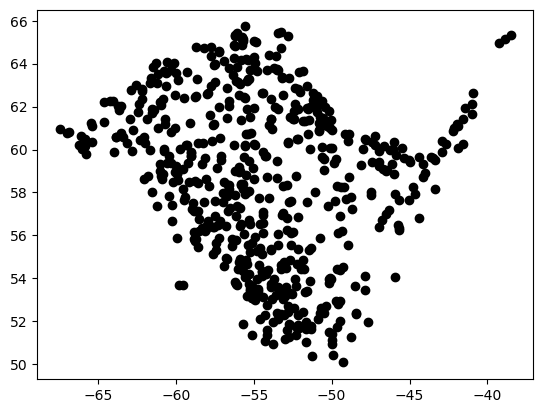

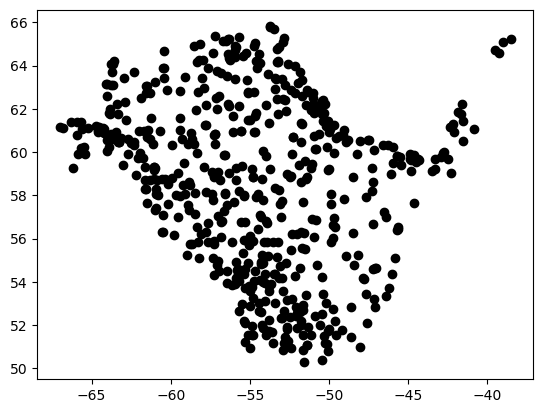

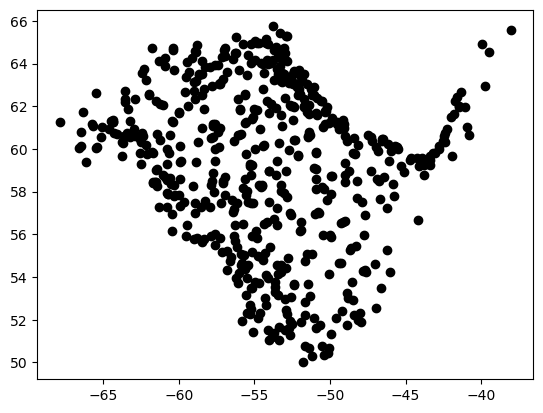

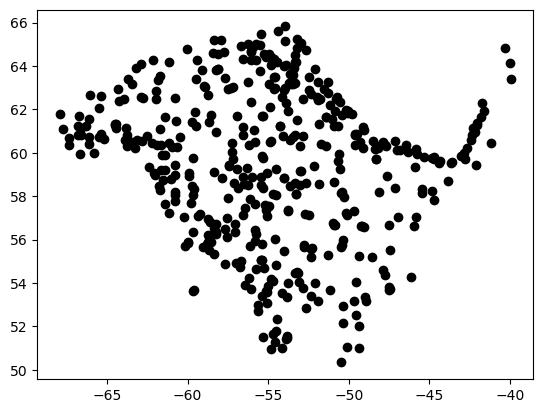

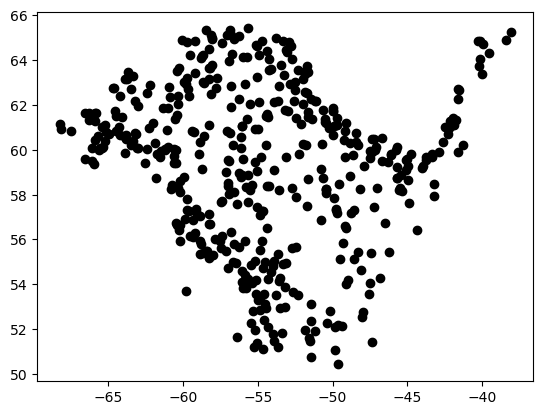

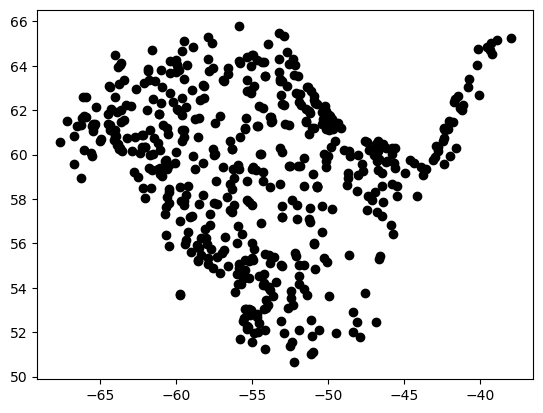

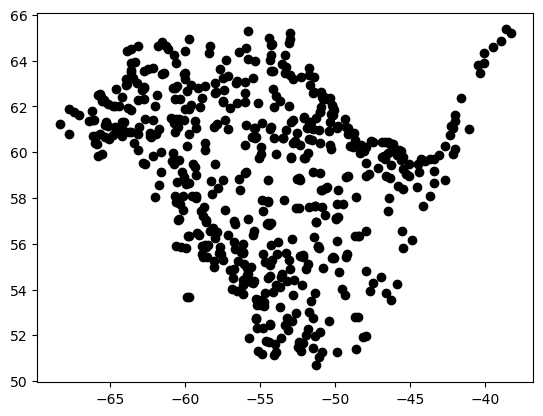

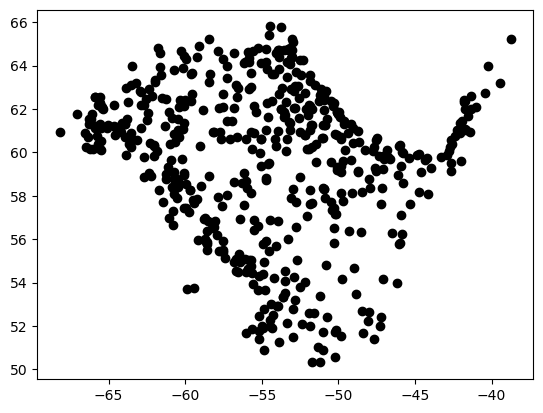

done


In [20]:
#if we want to load all the raw detection data for one subdomain

extraction_name='Labrador-2425-v3_0' #choose yours
path_save=path_data+'detection_'+extraction_name+'/raw_detection/'


print('load detection')


#loop because of the chunks
namefiles=glob.glob(path_save+'*detection*.nc');namefiles.sort()
lon_all=[]
lat_all=[]
juld_all=[]
cycle_all=[]
r_all=[]
v_all=[]
a_all=[]
perc_gaps_all=[]
pol_all=[]
contour_lon_all=[]
contour_lat_all=[]
ipass_all=[]
cycles_avail=[]


for namefile in namefiles:
    #print(namefile)
    nc=Dataset(namefile)
    lon_all.append(nc['lon'][:])
    lat_all.append(nc['lat'][:])
    juld_all.append(nc['juld'][:])
    cycle_all.append(nc['cycle'][:])
    r_all.append(nc['r'][:])
    v_all.append(nc['v'][:])
    a_all.append(nc['a'][:])
    perc_gaps_all.append(nc['perc_gaps'][:])
    pol_all.append(nc['pol'][:])
    contour_lon_all.append(nc['clon'][:])
    contour_lat_all.append(nc['clat'][:])
    ipass_all.append(nc['ipass'][:])
    cycles_avail.append(np.unique(nc['cycle'][:]))
    nc.close()

lon_all=np.concatenate(lon_all,axis=0)
lat_all=np.concatenate(lat_all,axis=0)
juld_all=np.concatenate(juld_all,axis=0)
cycle_all=np.concatenate(cycle_all,axis=0)
r_all=np.concatenate(r_all,axis=0)
v_all=np.concatenate(v_all,axis=0)
a_all=np.concatenate(a_all,axis=0)
perc_gaps_all=np.concatenate(perc_gaps_all,axis=0)
pol_all=np.concatenate(pol_all,axis=0)
contour_lon_all=np.concatenate(contour_lon_all,axis=0)
contour_lat_all=np.concatenate(contour_lat_all,axis=0)
ipass_all=np.concatenate(ipass_all,axis=0)
cycles_avail=np.unique(np.concatenate(cycles_avail,axis=0))
lon_all=np.where(lon_all>180,lon_all-360,lon_all)

#plot the detection for each cycle
for icycle in range(len(cycles_avail)):
    take_cycle=cycle_all==cycles_avail[icycle]
    plt.plot(lon_all[take_cycle],lat_all[take_cycle],'ok')
    plt.show()

print('done')